# 04. FILIP ECG Comprehensive Diagnostic Suite

This notebook systematically executes the **FILIP ECG Visualization Diagnostic Suite** to analyze spatial text-patch alignment and register-token behavior:
1. **Configurable Target Sample**: Pick specific study IDs (e.g. `03579_hr` / `03579`).
2. **Ground Truth Labels Display**: Displays all ground truth diagnosis codes and full clinical descriptions.
3. **Fixed Preprocessing**: Ensures exact training preprocessing (`ExpandToSquare` + CLIP Normalization).
4. **Warm Red vs. Transparent Overlay**: Overlays heatmaps on the original ECG image where low values are transparent and high values glow in warm red.
5. **Patch Norm Diagnostics**: Measures $\|z_i\|_2$ (raw ViT) and $\|W z_i\|_2$ (projected) to detect register-like outlier tokens.
6. **3-Model Checkpoint Comparison**: Benchmarks Base CLIP vs. Stage 1 (MIMIC pretrain) vs. Stage 2 (PTB-XL downstream).
7. **Text-Independent Hotspot Test**: Evaluates whether blank background patches repeatedly win across unrelated terms.

In [1]:
import os
import sys
import random
import importlib
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms
from transformers import CLIPTokenizer

# Ensure project root (containing the 'filip' package) is in sys.path
current_dir = os.path.abspath(os.getcwd())
if os.path.basename(current_dir) == 'visualization':
    PROJECT_ROOT = os.path.abspath(os.path.join(current_dir, '..', '..'))
elif os.path.basename(current_dir) == 'filip':
    PROJECT_ROOT = os.path.abspath(os.path.join(current_dir, '..'))
else:
    PROJECT_ROOT = current_dir

if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

print(f"Project root resolved to: {PROJECT_ROOT}")

# Reload diagnostic_utils to prevent stale Jupyter kernel sys.modules cache
if 'filip.visualization.diagnostic_utils' in sys.modules:
    importlib.reload(sys.modules['filip.visualization.diagnostic_utils'])

try:
    from filip.visualization.diagnostic_utils import (
        ExpandToSquare,
        get_exact_training_transform,
        load_model_from_checkpoint,
        compute_patch_norms,
        compute_token_patch_similarity,
        compute_word_level_patch_similarity,
        compute_phrase_level_patch_similarity,
        compute_attention_rollout,
        run_text_independence_test,
        get_warm_red_transparent_cmap,
        plot_warm_red_overlay
    )
except ImportError:
    import filip.visualization.diagnostic_utils as diag_utils
    importlib.reload(diag_utils)
    from filip.visualization.diagnostic_utils import (
        ExpandToSquare,
        get_exact_training_transform,
        load_model_from_checkpoint,
        compute_patch_norms,
        compute_token_patch_similarity,
        compute_word_level_patch_similarity,
        compute_phrase_level_patch_similarity,
        compute_attention_rollout,
        run_text_independence_test,
        get_warm_red_transparent_cmap,
        plot_warm_red_overlay
    )

from filip.data.dataset import ECGImageDataset

SUBCLASS_DESCRIPTIONS = {
    'AMI': 'anterior myocardial infarction',
    'ALMI': 'anterolateral myocardial infarction',
    'ASMI': 'anteroseptal myocardial infarction',
    'ILMI': 'inferolateral myocardial infarction',
    'IMI': 'inferior myocardial infarction',
    'SEHYP': 'septal hypertrophy',
    'CRBBB': 'complete right bundle branch block',
    'WPW': 'Wolff-Parkinson-White syndrome',
    'LAO/LAE': 'left atrial overload or enlargement',
    'NORM': 'normal sinus rhythm',
    'ISC': 'ischemic ST-T changes',
    'AVB': 'atrioventricular block',
    'RAO/RAE': 'right atrial overload or enlargement',
    'LMI': 'lateral myocardial infarction',
    'ISCI': 'ischemic infarction',
    'ISCA': 'ischemic anterior changes',
    'NST': 'non-specific ST-T changes',
    'CLBBB': 'complete left bundle branch block',
    'ILBBB': 'incomplete left bundle branch block',
    'IRBBB': 'incomplete right bundle branch block',
    'PMI': 'posterior myocardial infarction',
    'RVH': 'right ventricular hypertrophy',
    'IVCD': 'intraventricular conduction delay'
}

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using diagnostic execution device: {device}")
warm_red_cmap = get_warm_red_transparent_cmap()

/home/qfbqt/miniconda3/envs/gem/lib/python3.10/site-packages/torch/cuda/__init__.py:65: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/home/qfbqt/miniconda3/envs/gem/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Project root resolved to: /home/qfbqt/repo/GEM-fork
Using diagnostic execution device: cuda


## 1. Select Target Sample (`03579_hr`) & Display Ground Truth Labels

Initialized standard CLIPVisionModel from openai/clip-vit-large-patch14 with image_size=224, patch_size=14
Initialized standard CLIPVisionModel from openai/clip-vit-large-patch14 with image_size=224, patch_size=14
Selected Sample Index : 1008 / 2158
Selected Study ID     : 09010_hr
Raw Image Size (W x H): 2200 x 1700
Ground Truth Codes    : ['NORM']
Ground Truth Phrases  : ['normal sinus rhythm']


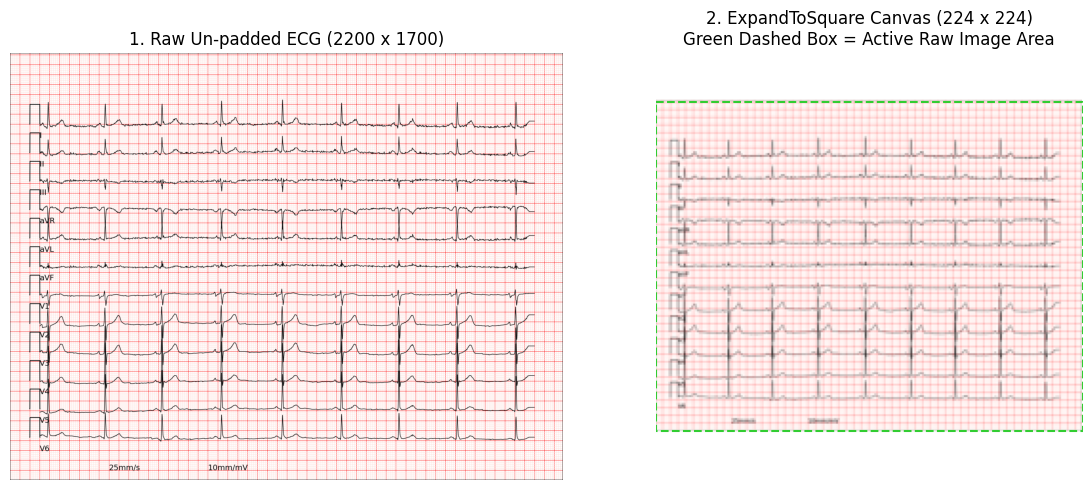

In [2]:
from filip.visualization.diagnostic_utils import (
    get_padding_info, map_patch_to_raw_pixels, plot_warm_red_overlay,
    ExpandToSquare, get_exact_training_transform, load_model_from_checkpoint,
    compute_patch_norms, compute_token_patch_similarity,
    compute_word_level_patch_similarity, compute_phrase_level_patch_similarity,
    compute_attention_rollout, run_text_independence_test
)
from filip.data.dataset import ECGImageDataset

TARGET_STUDY_ID = ""

ckpt_stg1_paths = [
    os.path.join(PROJECT_ROOT, 'outputs', 'filip', 'vit_large_mimic_report_align_100', 'best.pt'),
    os.path.join(PROJECT_ROOT, 'outputs', 'filip', 'mimic_report_alignment_vit_large_pretrain', 'checkpoints', 'best.pt'),
    os.path.join(PROJECT_ROOT, 'outputs', 'filip', 'mimic_report_alignment_pretrain', 'checkpoints', 'best.pt')
]
ckpt_stg1 = next((p for p in ckpt_stg1_paths if os.path.exists(p)), None)

ckpt_stg2_paths = [
    os.path.join(PROJECT_ROOT, 'outputs', 'filip', 'vit_large_ptbxl_sub_report_align_adapt_100', 'best.pt'),
    os.path.join(PROJECT_ROOT, 'outputs', 'filip', 'ptbxl_sub_report_align_adapt_100', 'best.pt')
]
ckpt_stg2 = next((p for p in ckpt_stg2_paths if os.path.exists(p)), None)

model_stg1, config_stg1 = load_model_from_checkpoint(ckpt_stg1, device=device)
model_stg2, config_stg2 = load_model_from_checkpoint(ckpt_stg2, device=device)
tokenizer = CLIPTokenizer.from_pretrained(config_stg1.get('model', {}).get('text_encoder', 'openai/clip-vit-large-patch14'))

image_size = config_stg1.get('model', {}).get('image_size', 224)
patch_size = config_stg1.get('model', {}).get('patch_size', 14)
grid_size = image_size // patch_size
data_root = os.path.join(PROJECT_ROOT, config_stg1.get('data_root', 'data/ptbxl_sub_class/'))
if not os.path.exists(data_root):
    data_root = os.path.join(PROJECT_ROOT, 'data', 'ptbxl_sub_class')

dataset_name = config_stg1.get('dataset_name', 'ptbxl_sub')
transform = get_exact_training_transform(image_size=image_size)
test_dataset = ECGImageDataset(data_root=data_root, split='test', dataset_name=dataset_name, transform=transform)

selected_idx = None
if TARGET_STUDY_ID.strip():
    target_clean = TARGET_STUDY_ID.strip().lower()
    for idx, record in enumerate(test_dataset.records):
        rec_id = str(record.get('study_id', record.get('ecg_id', ''))).lower()
        if rec_id == target_clean or f"{rec_id}_hr" == target_clean or target_clean.startswith(rec_id):
            selected_idx = idx
            break
    if selected_idx is None:
        print(f"Study ID '{TARGET_STUDY_ID}' not found in test set. Defaulting to random selection.")

if selected_idx is None:
    selected_idx = random.randint(0, len(test_dataset) - 1)

sample = test_dataset[selected_idx]
input_tensor = sample['images'].unsqueeze(0).to(device)
image_tensor = input_tensor
study_id = sample['sample_ids']
diagnosis_targets = sample['diagnosis_targets']

raw_img_path = os.path.join(data_root, 'images', f"{study_id}-0.png")
if not os.path.exists(raw_img_path):
    raw_img_path = os.path.join(data_root, f"{study_id}-0.png")
raw_image = Image.open(raw_img_path).convert('RGB') if os.path.exists(raw_img_path) else Image.new('RGB', (image_size, image_size), (255, 255, 255))
padded_square = ExpandToSquare(background_color=(255, 255, 255))(raw_image).resize((image_size, image_size))

gt_labels = []
gt_full_descriptions = []
if diagnosis_targets is not None:
    for i, target_val in enumerate(diagnosis_targets):
        if target_val > 0.5 and i < len(test_dataset.diagnosis_list):
            diag_code = test_dataset.diagnosis_list[i]
            gt_labels.append(diag_code)
            gt_full_descriptions.append(SUBCLASS_DESCRIPTIONS.get(diag_code, diag_code))

print("=" * 75)
print(f"Selected Sample Index : {selected_idx} / {len(test_dataset)}")
print(f"Selected Study ID     : {study_id}")
print(f"Raw Image Size (W x H): {raw_image.size[0]} x {raw_image.size[1]}")
print(f"Ground Truth Codes    : {gt_labels if gt_labels else ['NORM']}")
print(f"Ground Truth Phrases  : {gt_full_descriptions if gt_full_descriptions else ['normal sinus rhythm']}")
print("=" * 75)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(raw_image)
axes[0].set_title(f"1. Raw Un-padded ECG ({raw_image.size[0]} x {raw_image.size[1]})")
axes[0].axis('off')

plot_warm_red_overlay(axes[1], padded_square, np.zeros((grid_size, grid_size)), vmin=0, vmax=1, raw_shape=raw_image.size)
axes[1].set_title(f"2. Cropped Heatmap View (Matching {raw_image.size[0]} x {raw_image.size[1]})")
axes[1].axis('off')
plt.tight_layout()
plt.show()


## 2. Load Checkpoints for 3-Model Comparison

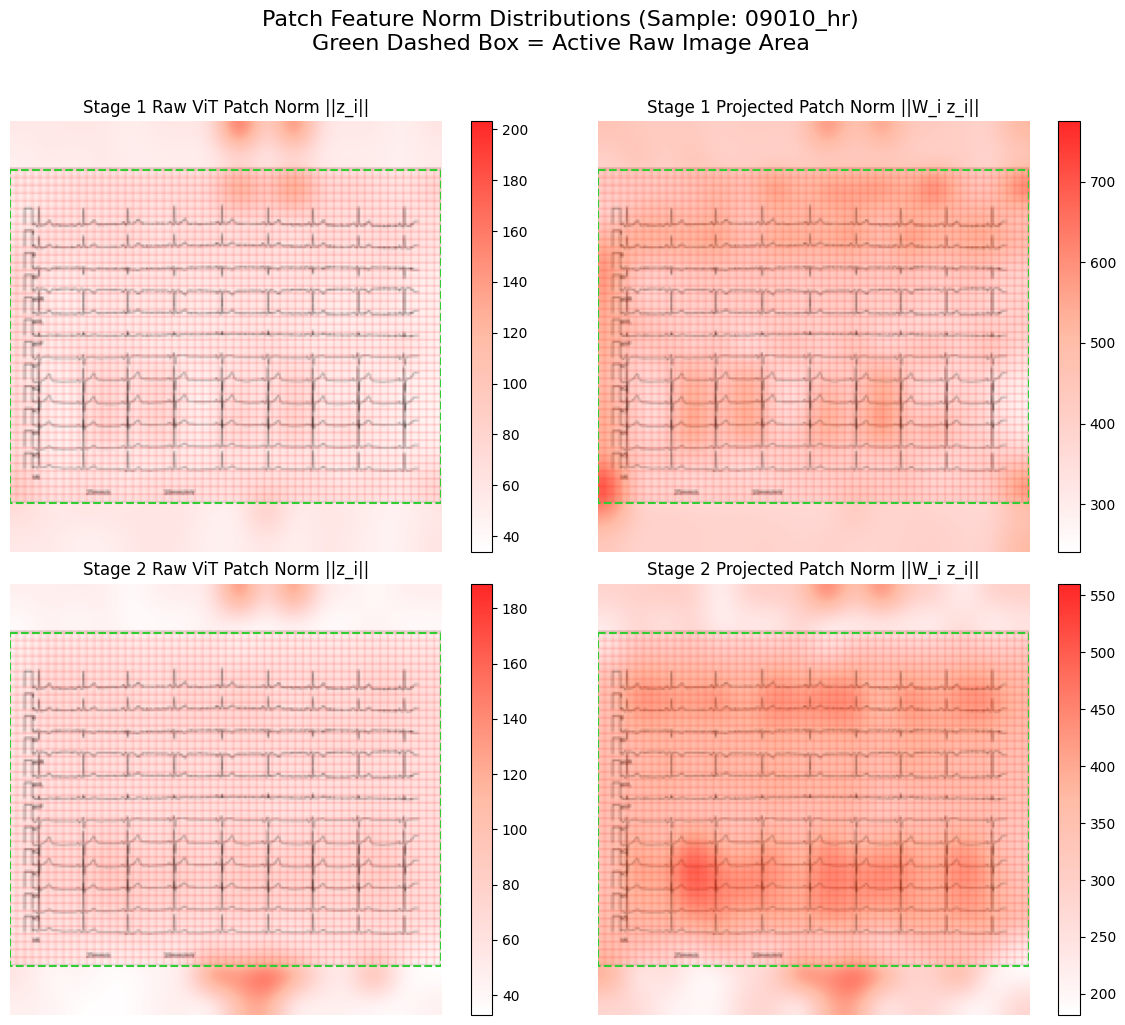

In [3]:
from filip.visualization.diagnostic_utils import load_base_clip_model

# Load Base CLIP Vision Model for comparison
base_vision_encoder, base_text_encoder, base_tokenizer = load_base_clip_model(device=device)
print("Base CLIP Vision & Text Models loaded successfully!")
print(f"Stage 1 Checkpoint: {ckpt_stg1}")
print(f"Stage 2 Checkpoint: {ckpt_stg2}")
print(f"Target Study ID:   {study_id} (Raw Shape: {raw_image.size[0]} x {raw_image.size[1]})")


## 3. Patch Norm Diagnostics (Raw $||z_i||_2$ vs. Projected $||W z_i||_2$)

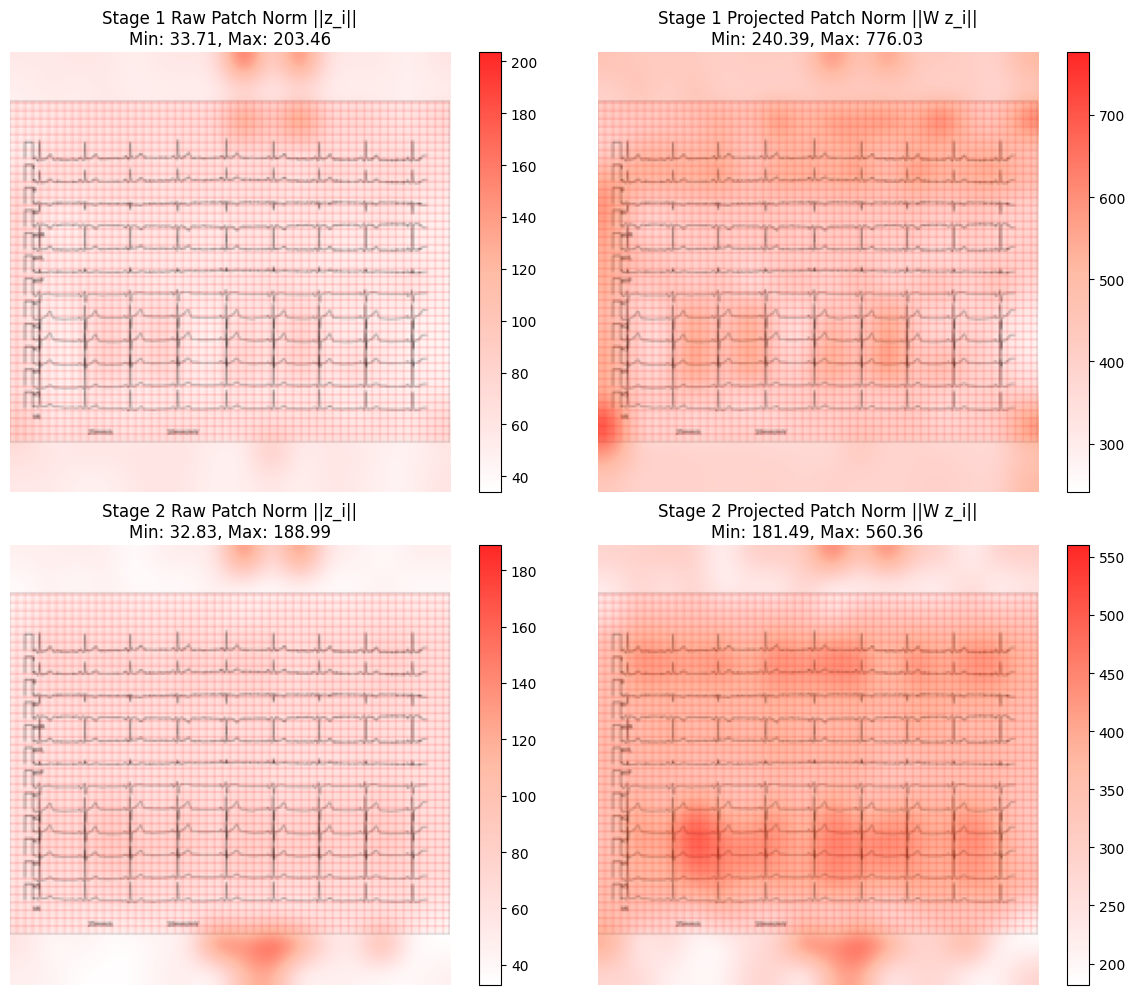

In [4]:
raw_norm_stg1, proj_norm_stg1, *reg1 = compute_patch_norms(model_stg1, input_tensor)
raw_norm_stg2, proj_norm_stg2, *reg2 = compute_patch_norms(model_stg2, input_tensor)

if reg1 and reg1[0] is not None:
    print(f"Stage 1 Register Token Norms ||r_k||: {reg1[0]}")
if reg2 and reg2[0] is not None:
    print(f"Stage 2 Register Token Norms ||r_k||: {reg2[0]}")

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Stage 1 Raw Patch Norm
im0 = plot_warm_red_overlay(axes[0, 0], padded_square, raw_norm_stg1.reshape(grid_size, grid_size),
                            title=f"Stage 1 Raw Patch Norm ||z_i||\nMin: {raw_norm_stg1.min():.2f}, Max: {raw_norm_stg1.max():.2f}",
                            raw_shape=raw_image.size)
fig.colorbar(im0, ax=axes[0, 0])

# Stage 1 Projected Patch Norm
im1 = plot_warm_red_overlay(axes[0, 1], padded_square, proj_norm_stg1.reshape(grid_size, grid_size),
                            title=f"Stage 1 Projected Patch Norm ||W z_i||\nMin: {proj_norm_stg1.min():.2f}, Max: {proj_norm_stg1.max():.2f}",
                            raw_shape=raw_image.size)
fig.colorbar(im1, ax=axes[0, 1])

# Stage 2 Raw Patch Norm
im2 = plot_warm_red_overlay(axes[1, 0], padded_square, raw_norm_stg2.reshape(grid_size, grid_size),
                            title=f"Stage 2 Raw Patch Norm ||z_i||\nMin: {raw_norm_stg2.min():.2f}, Max: {raw_norm_stg2.max():.2f}",
                            raw_shape=raw_image.size)
fig.colorbar(im2, ax=axes[1, 0])

# Stage 2 Projected Patch Norm
im3 = plot_warm_red_overlay(axes[1, 1], padded_square, proj_norm_stg2.reshape(grid_size, grid_size),
                            title=f"Stage 2 Projected Patch Norm ||W z_i||\nMin: {proj_norm_stg2.min():.2f}, Max: {proj_norm_stg2.max():.2f}",
                            raw_shape=raw_image.size)
fig.colorbar(im3, ax=axes[1, 1])

plt.suptitle(f"Patch Feature Norm Diagnostics (Sample: {study_id})\n(Heatmaps Scaled to Match Raw Image)", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()


## 4. Subword Token, Whole-Word, and Phrase-Level Alignment Maps (Target & GT Diagnoses)

Visualizing Alignment for Clinical Phrase: 'myocardial infarction' (Study ID: 09010_hr)
CLIP Subword Tokens: ['myo', 'cardi', 'al', 'inf', 'ar', 'ction']


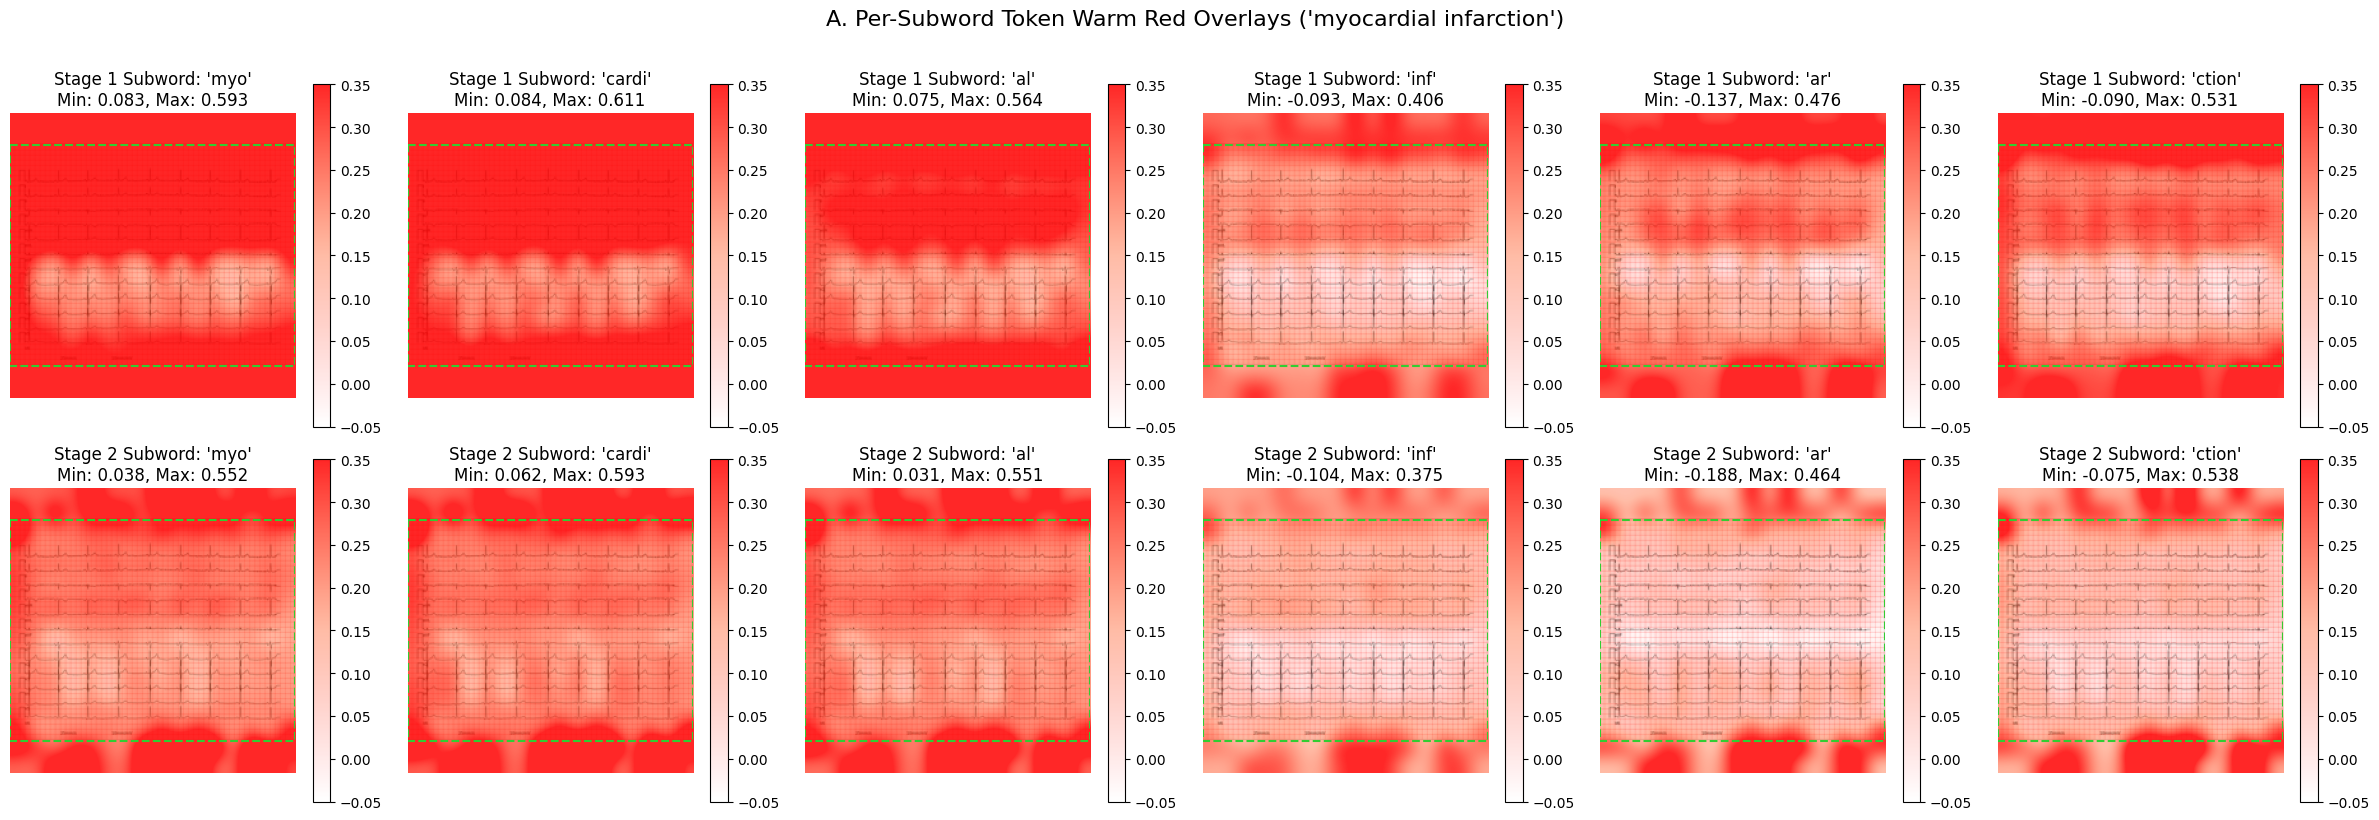

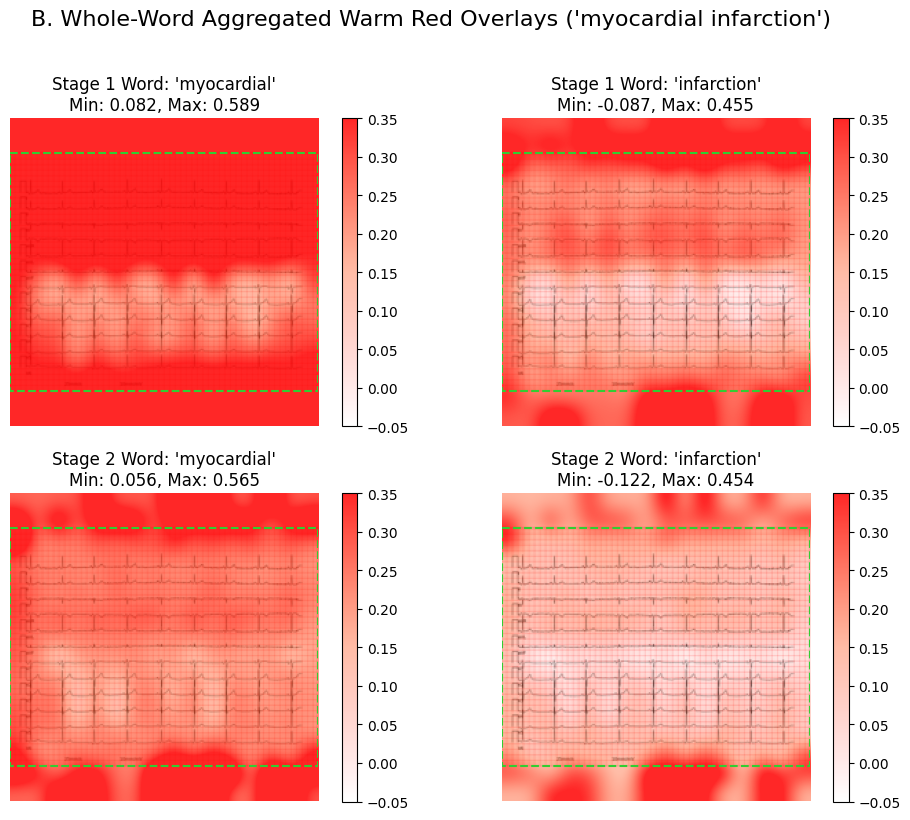

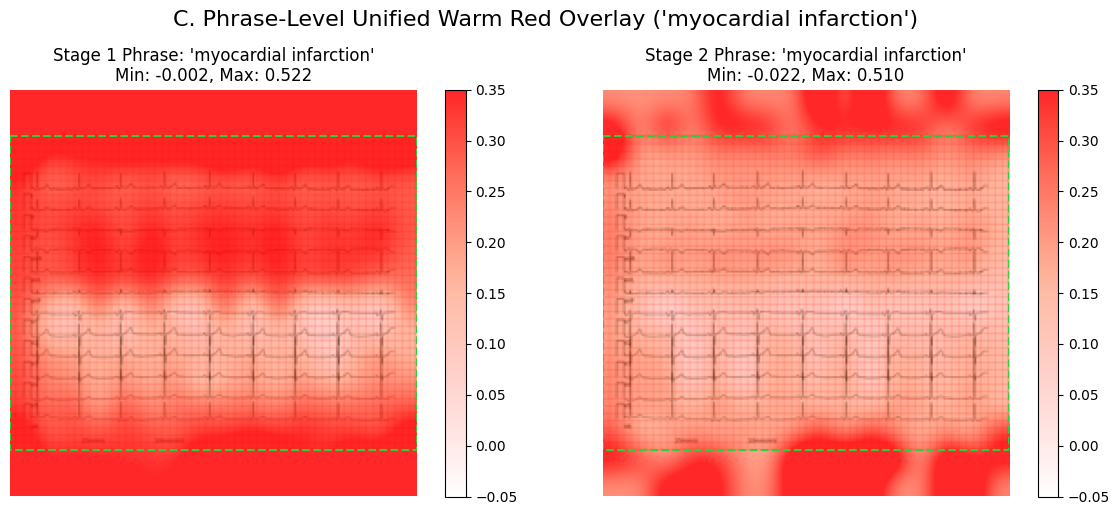

In [5]:
target_phrase = gt_full_descriptions[0] if gt_full_descriptions else "myocardial infarction"
print(f"Visualizing Alignment for Clinical Phrase: '{target_phrase}' (Study ID: {study_id})")

per_token_stg1, token_list = compute_token_patch_similarity(model_stg1, tokenizer, input_tensor, target_phrase, device=device)
per_token_stg2, _ = compute_token_patch_similarity(model_stg2, tokenizer, input_tensor, target_phrase, device=device)

print(f"CLIP Subword Tokens: {list(per_token_stg1.keys())}")

# A. Plot per subword token with Warm Red vs Transparent Overlay
num_tokens = len(per_token_stg1)
fig, axes = plt.subplots(2, num_tokens, figsize=(4 * num_tokens, 8))
if num_tokens == 1:
    axes = np.array([[axes[0]], [axes[1]]])

for idx, (token_name, stats_stg1) in enumerate(per_token_stg1.items()):
    stats_stg2 = per_token_stg2[token_name]
    sim1 = stats_stg1['similarity_map'].reshape(grid_size, grid_size)
    sim2 = stats_stg2['similarity_map'].reshape(grid_size, grid_size)
    
    # Stage 1 Subword Overlay
    im_1 = plot_warm_red_overlay(axes[0, idx], padded_square, sim1, vmin=-0.05, vmax=0.35, raw_shape=raw_image.size)
    axes[0, idx].set_title(f"Stage 1 Subword: '{token_name}'\nMin: {stats_stg1['min']:.3f}, Max: {stats_stg1['max']:.3f}")
    fig.colorbar(im_1, ax=axes[0, idx])
    
    # Stage 2 Subword Overlay
    im_2 = plot_warm_red_overlay(axes[1, idx], padded_square, sim2, vmin=-0.05, vmax=0.35, raw_shape=raw_image.size)
    axes[1, idx].set_title(f"Stage 2 Subword: '{token_name}'\nMin: {stats_stg2['min']:.3f}, Max: {stats_stg2['max']:.3f}")
    fig.colorbar(im_2, ax=axes[1, idx])

plt.suptitle(f"A. Per-Subword Token Warm Red Overlays ('{target_phrase}')", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

# B. Plot Whole-Word Aggregated Heatmaps
word_sims_stg1 = compute_word_level_patch_similarity(model_stg1, tokenizer, input_tensor, target_phrase, pooling='mean', device=device)
word_sims_stg2 = compute_word_level_patch_similarity(model_stg2, tokenizer, input_tensor, target_phrase, pooling='mean', device=device)

fig, axes = plt.subplots(2, len(word_sims_stg1), figsize=(5 * len(word_sims_stg1), 8))
if len(word_sims_stg1) == 1:
    axes = np.array([[axes[0]], [axes[1]]])
for idx, (word_name, wstats1) in enumerate(word_sims_stg1.items()):
    wstats2 = word_sims_stg2[word_name]
    wsim1 = wstats1['similarity_map'].reshape(grid_size, grid_size)
    wsim2 = wstats2['similarity_map'].reshape(grid_size, grid_size)
    
    im1 = plot_warm_red_overlay(axes[0, idx], padded_square, wsim1, vmin=-0.05, vmax=0.35, raw_shape=raw_image.size)
    axes[0, idx].set_title(f"Stage 1 Word: '{word_name}'\nMin: {wstats1['min']:.3f}, Max: {wstats1['max']:.3f}")
    fig.colorbar(im1, ax=axes[0, idx])
    
    im2 = plot_warm_red_overlay(axes[1, idx], padded_square, wsim2, vmin=-0.05, vmax=0.35, raw_shape=raw_image.size)
    axes[1, idx].set_title(f"Stage 2 Word: '{word_name}'\nMin: {wstats2['min']:.3f}, Max: {wstats2['max']:.3f}")
    fig.colorbar(im2, ax=axes[1, idx])

plt.suptitle(f"B. Whole-Word Aggregated Warm Red Overlays ('{target_phrase}')", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

# C. Plot Phrase-Level Aggregated Heatmap
phrase_stg1 = compute_phrase_level_patch_similarity(model_stg1, tokenizer, input_tensor, target_phrase, pooling='mean', device=device)
phrase_stg2 = compute_phrase_level_patch_similarity(model_stg2, tokenizer, input_tensor, target_phrase, pooling='mean', device=device)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
psim1 = phrase_stg1['similarity_map'].reshape(grid_size, grid_size)
psim2 = phrase_stg2['similarity_map'].reshape(grid_size, grid_size)

pim1 = plot_warm_red_overlay(axes[0], padded_square, psim1, vmin=-0.05, vmax=0.35, raw_shape=raw_image.size)
axes[0].set_title(f"Stage 1 Phrase: '{target_phrase}'\nMin: {phrase_stg1['min']:.3f}, Max: {phrase_stg1['max']:.3f}")
fig.colorbar(pim1, ax=axes[0])

pim2 = plot_warm_red_overlay(axes[1], padded_square, psim2, vmin=-0.05, vmax=0.35, raw_shape=raw_image.size)
axes[1].set_title(f"Stage 2 Phrase: '{target_phrase}'\nMin: {phrase_stg2['min']:.3f}, Max: {phrase_stg2['max']:.3f}")
fig.colorbar(pim2, ax=axes[1])

plt.suptitle(f"C. Phrase-Level Unified Warm Red Overlay ('{target_phrase}')", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()


## 5. Text-Independent Hotspot Test

TEXT-INDEPENDENCE DIAGNOSTIC TEST RESULTS
Stage 1 Most Frequent Winning Patch across 8 terms: Patch #32 (Winning Freq: 37.5%)
Stage 2 Most Frequent Winning Patch across 8 terms: Patch #249 (Winning Freq: 37.5%)


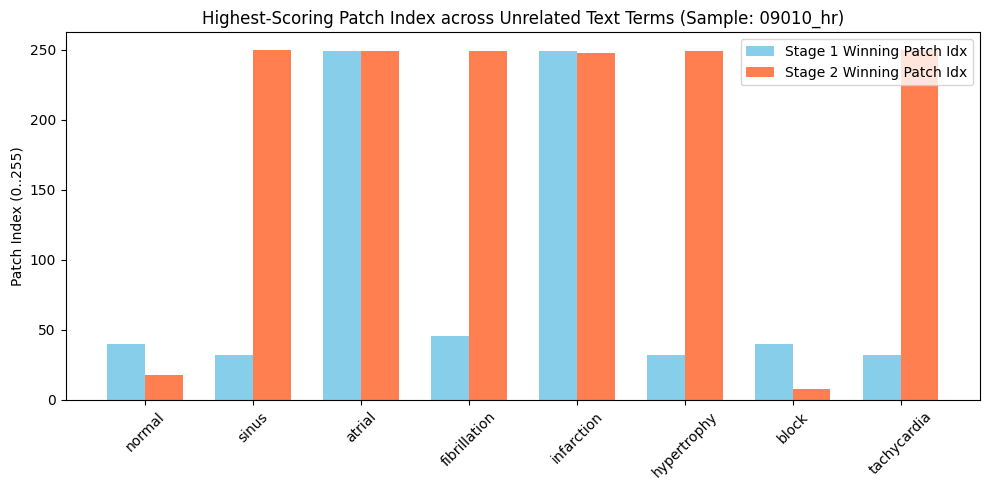

In [6]:
test_terms = ['normal', 'sinus', 'atrial', 'fibrillation', 'infarction', 'hypertrophy', 'block', 'tachycardia']
indep_results_stg1, common_patch_stg1, freq_stg1 = run_text_independence_test(model_stg1, tokenizer, image_tensor, test_terms, device=device)
indep_results_stg2, common_patch_stg2, freq_stg2 = run_text_independence_test(model_stg2, tokenizer, image_tensor, test_terms, device=device)

print("=" * 60)
print("TEXT-INDEPENDENCE DIAGNOSTIC TEST RESULTS")
print("=" * 60)
print(f"Stage 1 Most Frequent Winning Patch across 8 terms: Patch #{common_patch_stg1} (Winning Freq: {freq_stg1 * 100:.1f}%)")
print(f"Stage 2 Most Frequent Winning Patch across 8 terms: Patch #{common_patch_stg2} (Winning Freq: {freq_stg2 * 100:.1f}%)")

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(test_terms))
width = 0.35

stg1_patches = [v['max_patch_idx'] for v in indep_results_stg1.values()]
stg2_patches = [v['max_patch_idx'] for v in indep_results_stg2.values()]

ax.bar(x - width/2, stg1_patches, width, label='Stage 1 Winning Patch Idx', color='skyblue')
ax.bar(x + width/2, stg2_patches, width, label='Stage 2 Winning Patch Idx', color='coral')
ax.set_xticks(x)
ax.set_xticklabels(test_terms, rotation=45)
ax.set_ylabel("Patch Index (0..255)")
ax.set_title(f"Highest-Scoring Patch Index across Unrelated Text Terms (Sample: {study_id})")
ax.legend()
plt.tight_layout()
plt.show()

## 6. ViT Attention Rollout vs. Alignment Maps

In [ ]:
rollout_stg1 = compute_attention_rollout(model_stg1, input_tensor)
rollout_stg2 = compute_attention_rollout(model_stg2, input_tensor)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

im1 = plot_warm_red_overlay(axes[0], padded_square, rollout_stg1, raw_shape=raw_image.size)
axes[0].set_title("Stage 1 ViT Self-Attention Rollout Overlay")
fig.colorbar(im1, ax=axes[0])

im2 = plot_warm_red_overlay(axes[1], padded_square, rollout_stg2, raw_shape=raw_image.size)
axes[1].set_title("Stage 2 ViT Self-Attention Rollout Overlay")
fig.colorbar(im2, ax=axes[1])
plt.suptitle(f"ViT Self-Attention Rollout (Sample: {study_id})\n(Heatmap Scaled to Match Raw Image)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


SyntaxError: unterminated string literal (detected at line 13) (4035718705.py, line 13)

## 7. Diagnostic Summary & Root Cause Classification

Evaluate against the decision tree:
- **Case A (Inherited ViT Register Behavior)**: High patch norms and repeated background winner across Base CLIP, Stage 1, and Stage 2.
- **Case B (Stage-1 MIMIC Report Alignment Pretrain)**: Clean in Base CLIP, hotspot appears after Stage 1.
- **Case C (Stage-2 Downstream Alignment Drift)**: Clean in Stage 1, hotspot appears only in Stage 2.
- **Case D (Visualization Preprocessing Artifact)**: Corrected `ExpandToSquare` + CLIP normalization eliminates hotspot.